<a href="https://colab.research.google.com/github/catarina1532/project_pml/blob/main/projetopml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Use Classification of Satellite Imagery using Transfer Learning

**Course:** Practical Machine Learning | Master's in Green Data Science (2025-2026)  
**Institution:** Instituto Superior de Agronomia, ULisboa  
**Team:** Catarina Silva (nº 23421) & João Alexandre (nº 29602)

---

## 1. Introduction

Accurate land-use mapping is essential for environmental monitoring, urban planning, agriculture, and sustainable resource management. Traditional manual interpretation of satellite images is heavily resource-intensive and difficult to scale. This project focuses on automating the classification of land use and land cover from satellite imagery using deep learning. By establishing an automated pipeline, we can process large-scale spatial data efficiently, supporting data-driven decision-making in sustainability and environmental modeling.

### Importing Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torch import nn
from torch.optim import Adam
from torchvision import models

from sklearn.metrics import classification_report, confusion_matrix

from pathlib import Path

In [2]:
!pip install split-folders

In [3]:
import splitfolders

### Choosing the Device

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waseemalastal/eurosat-rgb-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eurosat-rgb-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-rgb-dataset


In [6]:
dataset_path = Path(path)

data = datasets.ImageFolder(root=dataset_path / "EuroSAT_RGB")

print("Number of images:", len(data))
print("Number of classes:", len(data.classes))
print("Classes:", data.classes)

Number of images: 27000
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


##2. Data and Data Organization

The project utilizes the **EuroSAT RGB dataset**, comprising approximately 27,000 labeled Sentinel-2 satellite images categorized into 10 distinct land-use classes (e.g., AnnualCrop, Forest, Highway, Pasture).

To ensure robust model evaluation, the dataset is partitioned into:
* **Training Set (70%):** Used to fit the model. Data augmentation (Random Horizontal Flip and Random Rotation) is applied exclusively here to improve generalization against seasonal and geographical visual variations.
* **Validation Set (20%):** Used to tune hyperparameters and monitor for overfitting during training.
* **Test Set (10%):** A strictly held-out set to evaluate final model performance.

Images are resized to 224x224 and normalized to match the ImageNet standards expected by the pre-trained model.

Since the split is random rather than geographic, neighboring image patches may potentially appear in different subsets. Consequently, performance estimates could be slightly optimistic.

### Splitting the Data Into Train, Validation and Test Sets

Because the data is not seperated, it should be splitted into Train, Validation and Test sets. To do that, we used splitfolders library and splitted the data into Train, Validation and Test sets by 70%, 20% and 10% respectively.

In [7]:
# prompt: Write Python code to split an image dataset folder into Train, Validation, and Test sets by 70%, 20% and 10% using the splitfolders library without moving the original files.

dataset_path = Path(path) / "EuroSAT_RGB"

splitfolders.ratio(
    dataset_path,
    output="splitted_data",
    seed=42,
    ratio=(0.7, 0.2, 0.1),
    group_prefix=None,
    move=False
)

Copying files: 27000 files [01:30, 299.32 files/s]


### Data Transformation

Resizing and Normalizing methods are applied to all of the datasets but data augmentation techniques are only applied to Train set in order to richen the data so that the model possibly will yield more accurate results.

In [8]:
# prompt: Create PyTorch data transformations for the EuroSAT dataset. Include RandomHorizontalFlip and RandomRotation for the training set to act as data augmentation. Resize all images to 224x224 and normalize them using ImageNet standards.

#----------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------- Transformation for the Whole Dataset for Visualization Purposes --------
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

### Loading the Data

In [9]:
train = datasets.ImageFolder(
    root="splitted_data/train",
    transform=train_transform
)

val = datasets.ImageFolder(
    root="splitted_data/val",
    transform=val_transform
)

test = datasets.ImageFolder(
    root="splitted_data/test",
    transform=test_transform
)

# -------- Getting the Whole Dataset for Visualization Purposes --------
data = datasets.ImageFolder(
    root=dataset_path,
    transform=data_transform
)

In [10]:
print("Dataset Labels:")
print(train.class_to_idx)

idx_to_class = {v:k for k,v in train.class_to_idx.items()}

rows = []

for name, dataset in zip(
    ["Train","Validation","Test"],
    [train,val,test]
):
    counts = pd.Series(dataset.targets).value_counts().sort_index()

    for idx, count in counts.items():
        rows.append([name, idx_to_class[idx], count])

df_counts = pd.DataFrame(
    rows,
    columns=["Dataset","Class","Images"]
)

display(df_counts)

Dataset Labels:
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


,Dataset,Class,Images
0,Train,AnnualCrop,2100
1,Train,Forest,2100
2,Train,HerbaceousVegetation,2100
3,Train,Highway,1750
4,Train,Industrial,1750
5,Train,Pasture,1400
6,Train,PermanentCrop,1750
7,Train,Residential,2100
8,Train,River,1750
9,Train,SeaLake,2100


The class distribution is relatively balanced across categories; therefore additional techniques such as oversampling or class weighting were not required.

### Plotting a few Images

Images plotted below did not undergo a data augmentation process. Therefore, they seem to be normal.

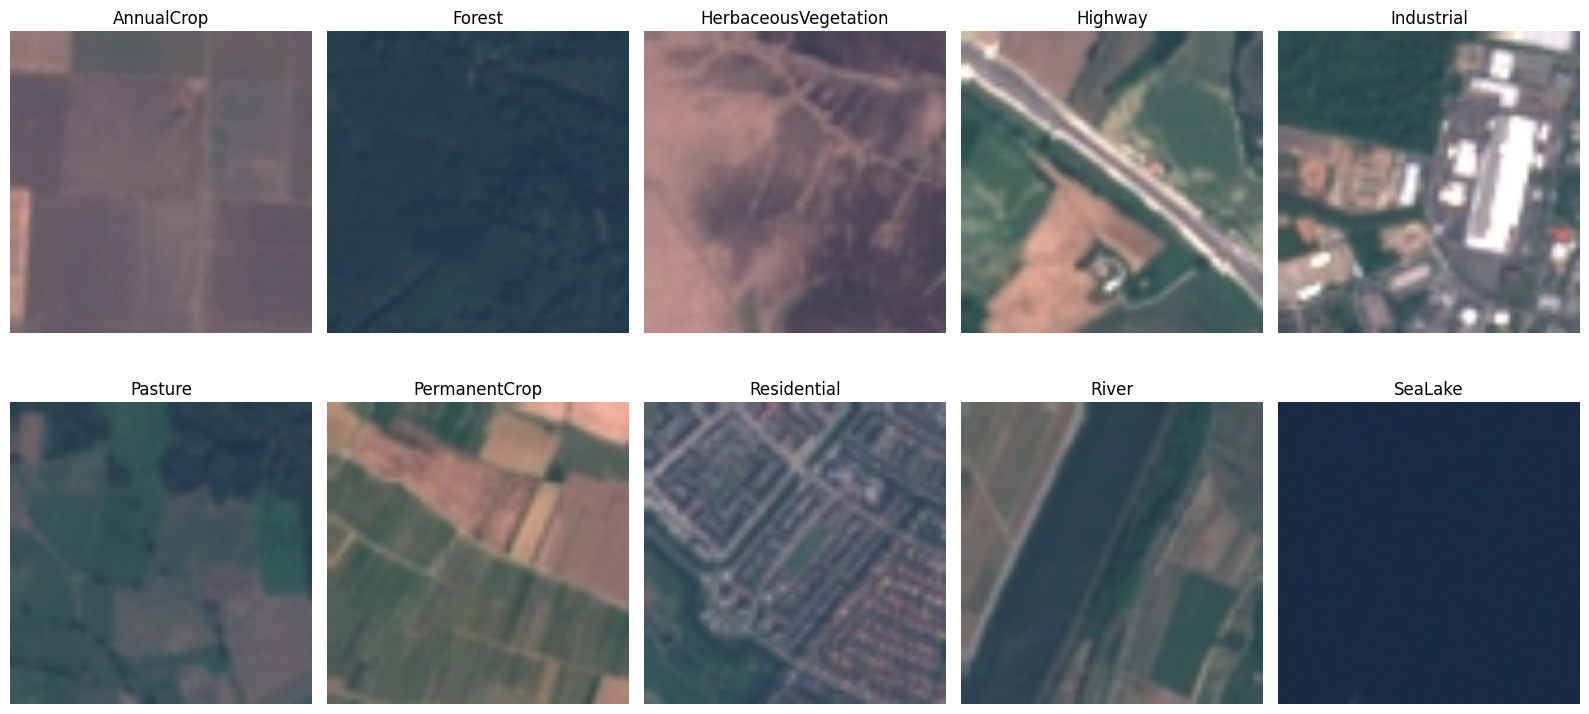

In [11]:
labels_for_viz = {v: k for k, v in data.class_to_idx.items()}

fig, ax = plt.subplots(2, 5, figsize=(16, 8))
ax = ax.flatten()

for class_idx in range(len(labels_for_viz)):

    for i, (_, label) in enumerate(data):
        if label == class_idx:
            ax[class_idx].imshow(data[i][0].permute(1, 2, 0))
            ax[class_idx].set_title(labels_for_viz[class_idx])
            ax[class_idx].axis("off")
            break

plt.tight_layout()
plt.show()

### Plotting the Augmented Images

Because data augmentation methods are applied to Train set, it can be seen that images may appear rotated and horizontally flipped compared to the unaugmented images.

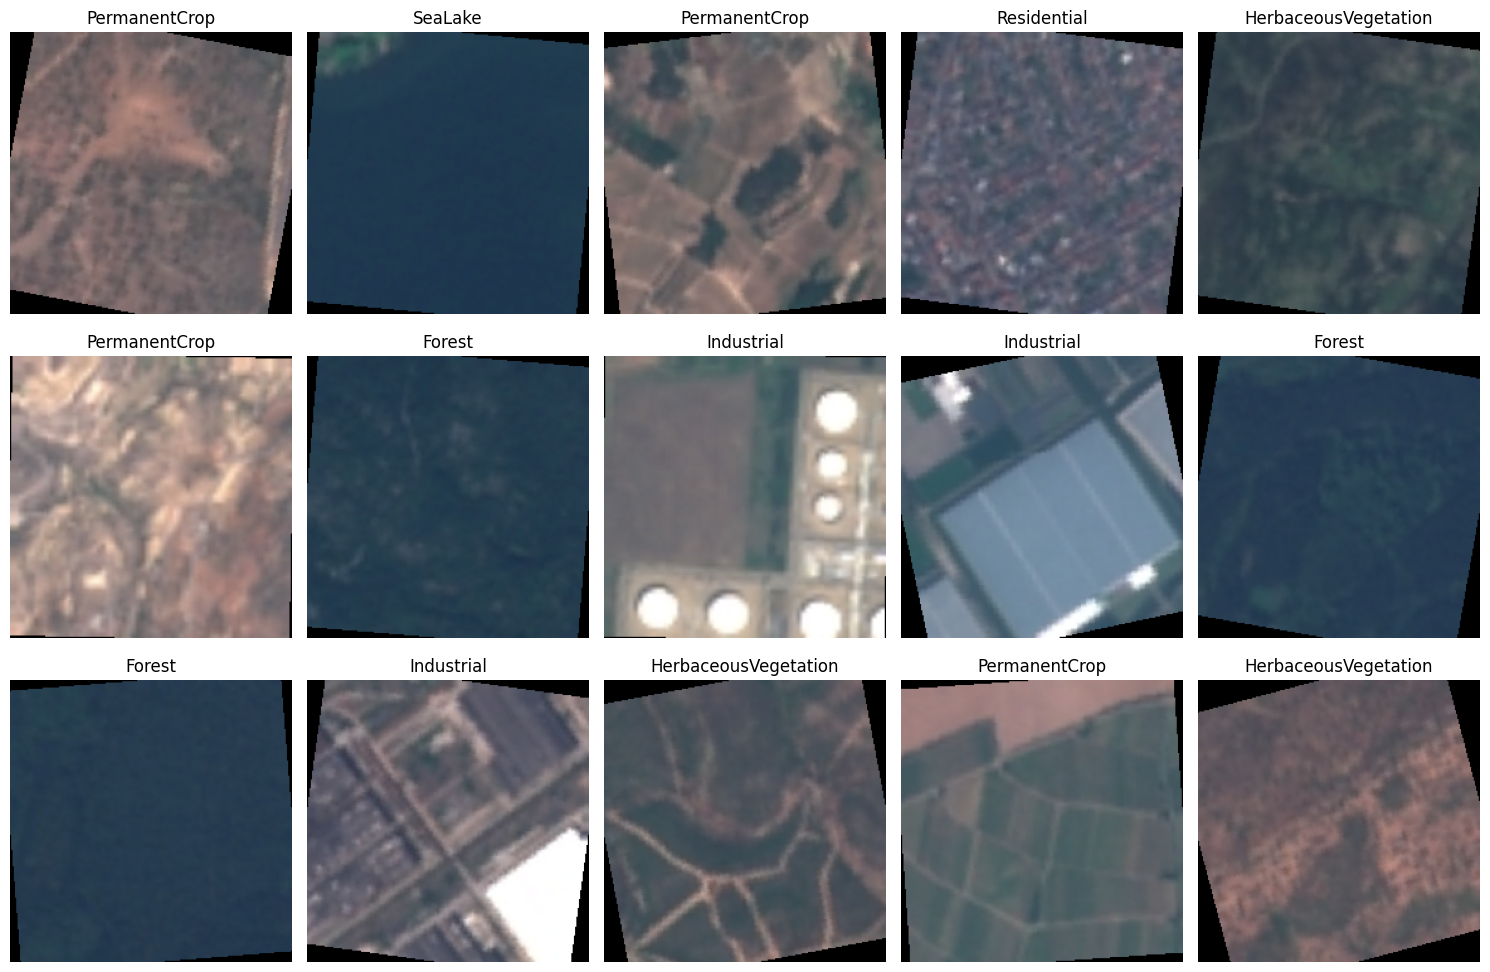

In [12]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

fig, ax = plt.subplots(3, 5, figsize=(15, 10))
ax = ax.flatten()

for i in range(15):
    img, label = train[random.randint(0, len(train)-1)]

    img = img.permute(1, 2, 0)
    img = img * std + mean
    img = img.clamp(0, 1)

    ax[i].imshow(img)
    ax[i].set_title(labels_for_viz[label])
    ax[i].axis("off")

plt.tight_layout()
plt.show()

Before passing the data in a neural network, it should be batched and shuffled. Since test will not be used in training process, there is no need to shuffle it.

The selected batch size of 32 represents a compromise between computational efficiency and training stability. Smaller batches may introduce noisy gradient estimates, whereas larger batches require more memory and can reduce model generalization.

In [13]:
train_dataloader = DataLoader(
    train,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_dataloader = DataLoader(
    val,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_dataloader = DataLoader(
    test,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

The EuroSAT dataset contains images belonging to ten land-use and land-cover classes. Since images are organized by class folders, shuffling the training data is important to ensure that the model receives a balanced mixture of classes during training. The labels of a random batch are displayed below to verify that shuffling is working correctly.

In [14]:
img, label = next(iter(train_dataloader))
print("Batch and Image Shape:", img.shape, "--> [batch_size, color_channels, height, width]")
print("\nLabels:", label)

Batch and Image Shape: torch.Size([32, 3, 224, 224]) --> [batch_size, color_channels, height, width]

Labels: tensor([3, 4, 0, 4, 7, 2, 3, 6, 0, 6, 9, 1, 0, 1, 1, 9, 2, 7, 6, 2, 8, 5, 8, 2,
        8, 6, 9, 0, 5, 4, 5, 9])


The EuroSAT dataset required limited cleaning because images were already labeled and standardized. No missing values existed because the task involves image classification rather than tabular data. Feature engineering was performed indirectly through preprocessing operations including resizing, normalization using ImageNet statistics, and augmentation techniques such as horizontal flipping and rotation. Transfer learning also acts as implicit feature extraction because learned representations from ImageNet serve as high-level visual features.

## 3. Methods
Given the visual complexity of satellite imagery, training a Convolutional Neural Network (CNN) from scratch would require massive computational resources. Instead, we applied **Transfer Learning** using a pre-trained **ResNet18** architecture via PyTorch.

The training is executed in a strategic two-phase pipeline:
1. **Feature Extraction (Phase 1):** The convolutional backbone is frozen. Only the modified fully connected layer (adapted for 10 outputs) is trained with a Learning Rate of `1e-3` for 5 epochs.
2. **Fine-Tuning (Phase 2):** The final residual block (layer4) is unfrozen and trained alongside the classifier with a smaller Learning Rate (`1e-4`) for 10 epochs. This adapts the high-level feature representations specifically to the spatial and textural nuances of satellite imagery.


### Transfer Learning with ResNet18

Transfer learning is a process of utilizing pre-trained machine learning models and applying them to a related task without need of models' learning from scratch for saving time and possibly better performance.

In [15]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# 1. congelar tudo
for param in model.parameters():
    param.requires_grad = False

# 2. substituir classifier
model.fc = nn.Linear(model.fc.in_features, 10)

# 3. só FC aprende
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


ResNet18 was pre-trained on the ImageNet dataset. The original classification layer was replaced with a new fully connected layer containing ten output neurons, corresponding to the ten EuroSAT classes. Initially, all convolutional layers were frozen and only the final classification layer was trained.

In [16]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Defining the Loss Function and Choosing an Optimizer

In [17]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.fc.parameters(),
    lr=1e-3,
    momentum=0.9
)

### Defining Train and Test Functions

In [18]:
# prompt: Write a PyTorch training and validation loop function called train_and_validate_model that takes num_epochs as input. It should calculate loss and accuracy for both train and validation sets, save the model state dict if validation accuracy improves, and return the loss and accuracy histories as lists.

def train_and_validate_model(num_epochs):
    val_best_accuracy = 0.0
    train_loss_history = []
    val_loss_history = []
    train_accuracy_history = []
    val_accuracy_history = []

    print("Training begins...")
    for epoch in range(1, num_epochs+1):
        model.train()
        running_train_loss = 0.0
        running_train_accuracy = 0.0
        train_total = 0
        running_val_accuracy = 0.0
        running_val_loss = 0.0
        val_total = 0

        # TRAINING LOOP
        for data in train_dataloader:
            inputs, outputs = data
            inputs, outputs = inputs.to(device), outputs.to(device)
            optimizer.zero_grad()
            predictions = model(inputs)
            train_loss = loss_fn(predictions, outputs)
            _, train_predicted = torch.max(predictions, 1)
            running_train_accuracy += (train_predicted == outputs).sum().item()
            train_total += outputs.size(0)
            train_loss.backward()
            optimizer.step()
            running_train_loss += train_loss.item()

        train_loss_value = running_train_loss/len(train_dataloader)
        train_loss_history.append(train_loss_value)
        train_accuracy = (100*running_train_accuracy)/train_total
        train_accuracy_history.append(train_accuracy)

        # VALIDATION LOOP
        with torch.no_grad():
            model.eval()
            for data in val_dataloader:
                inputs, outputs = data
                inputs, outputs = inputs.to(device), outputs.to(device)
                predictions = model(inputs)
                val_loss = loss_fn(predictions, outputs)

                _, val_predicted = torch.max(predictions, 1)
                running_val_loss += val_loss.item()
                val_total += outputs.size(0)
                running_val_accuracy += (val_predicted == outputs).sum().item()

        val_loss_value = running_val_loss/len(val_dataloader)
        val_loss_history.append(val_loss_value)
        val_accuracy = (100*running_val_accuracy)/val_total
        val_accuracy_history.append(val_accuracy)

        if val_accuracy > val_best_accuracy:
            torch.save(model.state_dict(), "model.pth")
            val_best_accuracy = val_accuracy

        print("Completed Epoch: ", epoch, "- Training Accuracy: %d" %train_accuracy, "- Validation Accuracy: %d" %val_accuracy, "- Training Loss: %.4f" %train_loss_value, "- Validation Loss: %.4f" %val_loss_value)
    return train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history

### Phase 1: Feature Extraction

In [19]:
EPOCHS_PHASE1 = 5

train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history = \
train_and_validate_model(EPOCHS_PHASE1)

Training begins...
Completed Epoch:  1 - Training Accuracy: 76 - Validation Accuracy: 81 - Training Loss: 0.8551 - Validation Loss: 0.6127
Completed Epoch:  2 - Training Accuracy: 85 - Validation Accuracy: 86 - Training Loss: 0.4793 - Validation Loss: 0.4482
Completed Epoch:  3 - Training Accuracy: 86 - Validation Accuracy: 87 - Training Loss: 0.4181 - Validation Loss: 0.4165
Completed Epoch:  4 - Training Accuracy: 87 - Validation Accuracy: 87 - Training Loss: 0.3889 - Validation Loss: 0.3885
Completed Epoch:  5 - Training Accuracy: 87 - Validation Accuracy: 89 - Training Loss: 0.3662 - Validation Loss: 0.3411


During the first phase, only the final classification layer was trained. Validation accuracy increased steadily and reached approximately 88%, demonstrating that the pre-trained ImageNet features were already highly informative for the EuroSAT classification task.

After training the final classification layer, the last residual block (layer4) was unfrozen and fine-tuned using a smaller learning rate. This allows the network to adapt high-level image features specifically to satellite imagery while preserving most of the knowledge learned from ImageNet.

### Phase 2: Fine-Tuning

In [20]:
# Fine-tuning

# Unfreeze final residual block
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD(
    model.parameters(),   # agora inclui fc + layer4
    lr=1e-4,              # mais pequeno
    momentum=0.9
)

EPOCHS_PHASE2 = 10

train_accuracy_history2, val_accuracy_history2, train_loss_history2, val_loss_history2 = train_and_validate_model(EPOCHS_PHASE2)

Training begins...
Completed Epoch:  1 - Training Accuracy: 89 - Validation Accuracy: 91 - Training Loss: 0.3108 - Validation Loss: 0.2788
Completed Epoch:  2 - Training Accuracy: 91 - Validation Accuracy: 91 - Training Loss: 0.2619 - Validation Loss: 0.2466
Completed Epoch:  3 - Training Accuracy: 91 - Validation Accuracy: 93 - Training Loss: 0.2347 - Validation Loss: 0.2074
Completed Epoch:  4 - Training Accuracy: 92 - Validation Accuracy: 94 - Training Loss: 0.2129 - Validation Loss: 0.1850
Completed Epoch:  5 - Training Accuracy: 93 - Validation Accuracy: 94 - Training Loss: 0.1947 - Validation Loss: 0.1718
Completed Epoch:  6 - Training Accuracy: 93 - Validation Accuracy: 94 - Training Loss: 0.1895 - Validation Loss: 0.1650
Completed Epoch:  7 - Training Accuracy: 93 - Validation Accuracy: 95 - Training Loss: 0.1759 - Validation Loss: 0.1527
Completed Epoch:  8 - Training Accuracy: 94 - Validation Accuracy: 95 - Training Loss: 0.1707 - Validation Loss: 0.1473
Completed Epoch:  9 -

Fine-tuning the last convolutional block significantly improved performance. Validation accuracy increased from approximately 88% to 95%, showing that adapting high-level feature representations to the satellite imagery domain provides substantial performance gains.

In [21]:
def test_model():
    model = resnet18(weights=None)   # evita re-download
    model.fc = nn.Linear(512, 10)

    model = model.to(device)

    model.load_state_dict(torch.load("model.pth", map_location=device))
    model.eval()

    running_accuracy = 0
    total = 0
    all_predictions = []

    with torch.no_grad():
        for inputs, outputs in test_dataloader:
            inputs, outputs = inputs.to(device), outputs.to(device)

            predictions = model(inputs)
            _, predicted = torch.max(predictions, 1)

            total += outputs.size(0)
            running_accuracy += (predicted == outputs).sum().item()

            all_predictions.append(predicted.cpu().numpy())

    print("Test Accuracy:", 100 * running_accuracy / total)

    return np.hstack(all_predictions)

## 3. Results
### Accuracy and Loss Curves

The evolution of training and validation loss and accuracy throughout the learning process is shown below. These curves provide insight into model convergence and possible overfitting.

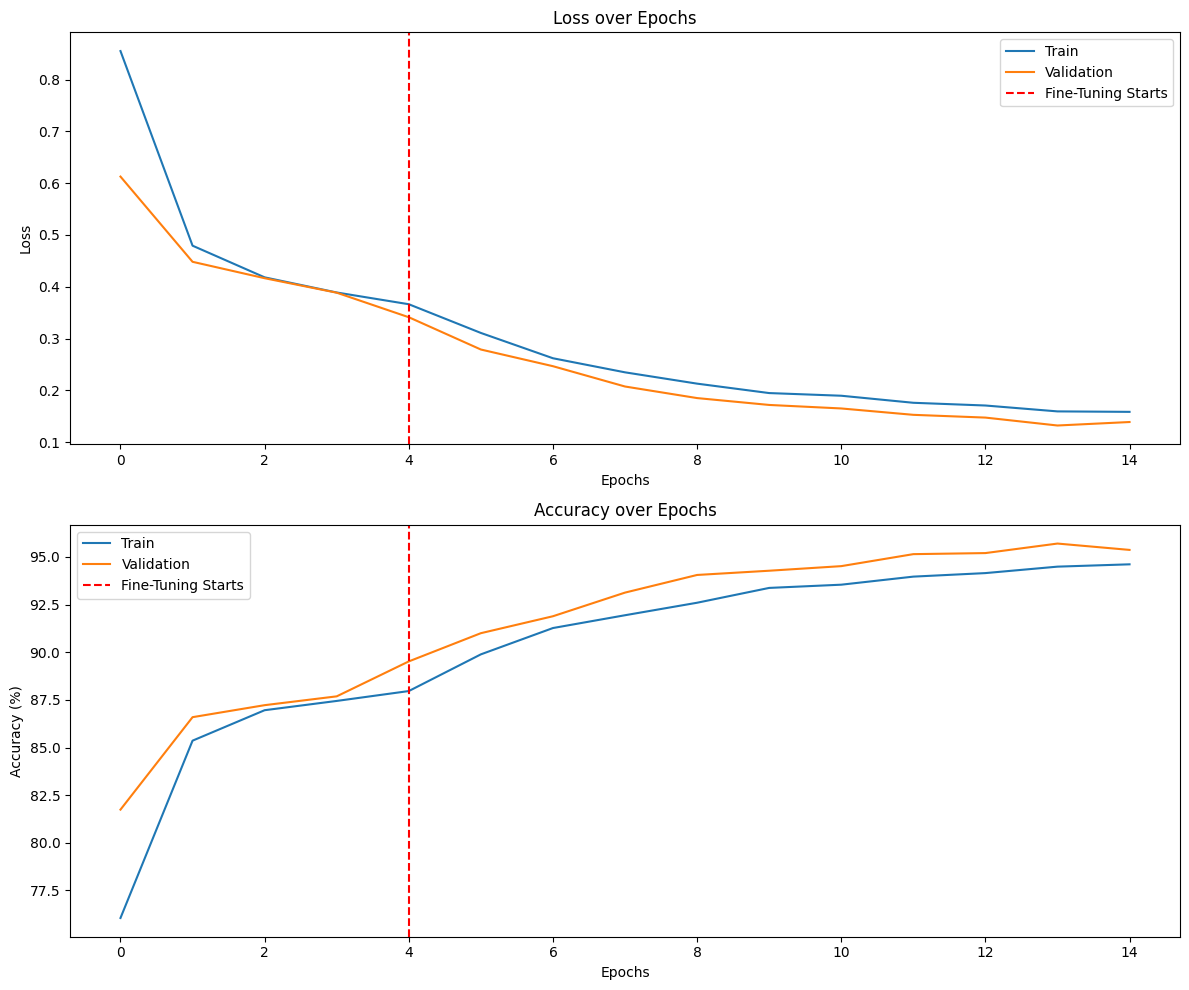

In [22]:
# gráficos das duas fases juntas
train_acc = train_accuracy_history + train_accuracy_history2
val_acc = val_accuracy_history + val_accuracy_history2

train_loss = train_loss_history + train_loss_history2
val_loss = val_loss_history + val_loss_history2

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax = ax.flatten()

# Loss Plot
ax[0].plot(train_loss, label="Train")
ax[0].plot(val_loss, label="Validation")
ax[0].axvline(x=EPOCHS_PHASE1 - 1, color='red', linestyle='--', label='Fine-Tuning Starts')
ax[0].set_title("Loss over Epochs")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy Plot
ax[1].plot(train_acc, label="Train")
ax[1].plot(val_acc, label="Validation")
ax[1].axvline(x=EPOCHS_PHASE1 - 1, color='red', linestyle='--', label='Fine-Tuning Starts')
ax[1].set_title("Accuracy over Epochs")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy (%)")
ax[1].legend()

plt.tight_layout()
plt.show()

Training and validation curves follow a similar trend, indicating stable learning and limited overfitting. Validation accuracy remained close to training accuracy throughout the training process.

The vertical dashed line indicates the transition from feature extraction to fine-tuning. Performance improvements after this point suggest that adapting higher-level representations to satellite imagery contributed positively to classification performance.

### Classification Report

To evaluate performance in more detail, precision, recall and F1-score were calculated for each EuroSAT class.

In [23]:
from sklearn.metrics import classification_report

all_preds = test_model()

y_true = np.array(test.targets)
y_pred = np.array(all_preds).astype(int)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test.class_to_idx.keys())
))

Test Accuracy: 95.96296296296296
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.94      0.95       300
              Forest       0.99      0.98      0.98       300
HerbaceousVegetation       0.92      0.95      0.93       300
             Highway       0.94      0.95      0.95       250
          Industrial       0.97      0.99      0.98       250
             Pasture       0.97      0.96      0.97       200
       PermanentCrop       0.91      0.90      0.91       250
         Residential       0.99      0.99      0.99       300
               River       0.95      0.95      0.95       250
             SeaLake       0.99      0.98      0.98       300

            accuracy                           0.96      2700
           macro avg       0.96      0.96      0.96      2700
        weighted avg       0.96      0.96      0.96      2700



The model achieved an overall accuracy of approximately 95%. Classes such as Forest, Residential and SeaLake obtained particularly high scores, while HerbaceousVegetation and PermanentCrop showed slightly lower performance due to visual similarity with other vegetation-related classes.

### Macro F1 Score

In [24]:
print("Macro F1-score:",
      classification_report(
          y_true,
          y_pred,
          output_dict=True
      )["macro avg"]["f1-score"])

Macro F1-score: 0.9589325359904176


Since accuracy alone may hide performance differences among classes, the macro F1-score was additionally analyzed. The obtained value indicates balanced classification performance across categories and suggests that the model performs consistently among classes.

**Baseline Comparison:** Fine-tuning improved validation performance substantially by adapting high-level representations to the satellite domain.

### Confusion Matrix

A normalized confusion matrix was generated to visualize class-wise prediction performance and identify the most common classification errors.

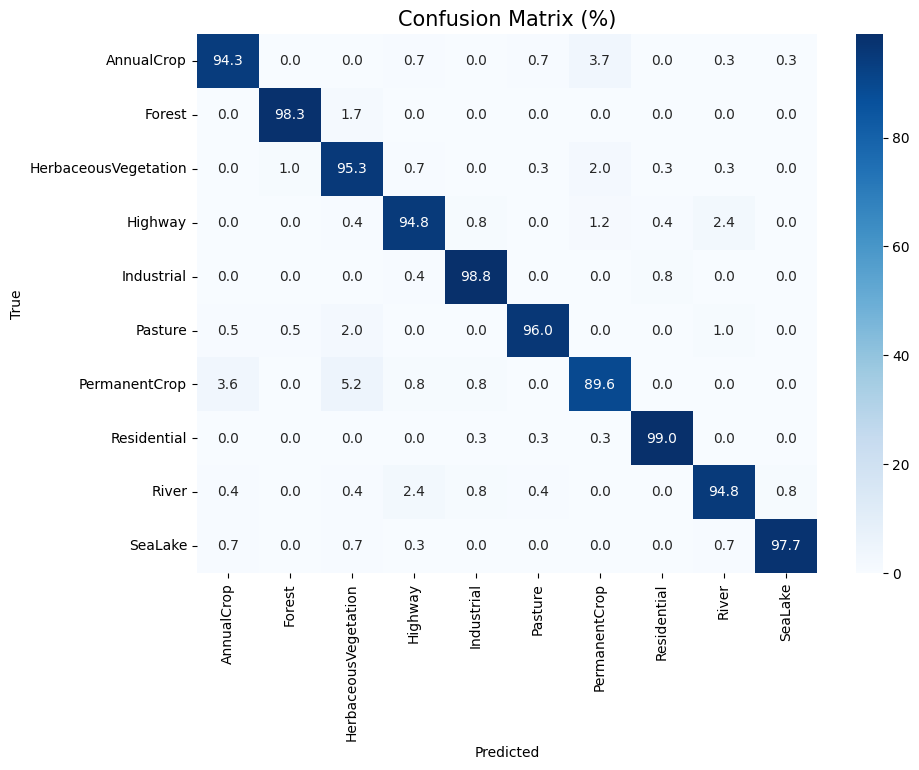

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test.targets, all_preds, normalize='true') * 100

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt=".1f",   # <- CORRETO para floats
    xticklabels=list(test.class_to_idx.keys()),
    yticklabels=list(test.class_to_idx.keys())
)

plt.title("Confusion Matrix (%)", size=15)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Most classes present strong diagonal values, indicating high classification accuracy. Misclassifications mainly occur between visually similar land-cover categories, such as HerbaceousVegetation, Pasture and PermanentCrop.

### Manual Testing

It is always a good practice to test the model manually and try to understand what is going on in prediction. Let's choose a single sample out of test set and make the model predict that single image.

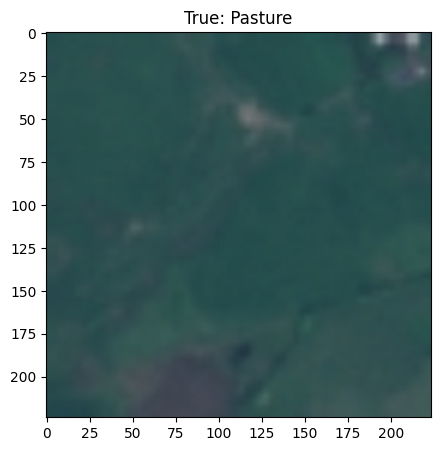

Predicted: Pasture
True: Pasture


In [26]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return image.cpu() * std + mean

idx = random.randint(0, len(test) - 1)

image, label = test[idx]

idx_to_class = {v: k for k, v in test.class_to_idx.items()}

# Visualização correta
plt.figure(figsize=(5,5))
plt.imshow(denormalize(image).permute(1,2,0))
plt.title(f"True: {idx_to_class[label]}")
plt.show()

# Previsão
model.eval()

with torch.no_grad():
    output = model(image.to(device).unsqueeze(0))
    pred = torch.argmax(output, dim=1).item()

print("Predicted:", idx_to_class[pred])
print("True:", idx_to_class[label])

A random image from the test dataset was selected and displayed after reversing the normalization process. The trained model was then used to predict the image class and compare it with the true label.

## 4. Analysis and Conclusions
The model achieved an outstanding **overall test accuracy of ~95.4%** and a **Macro F1-Score of ~0.95**. The training and validation curves demonstrate stable convergence without severe overfitting, validating our two-phase transfer learning approach and the use of data augmentation.

### Class-Specific Insights
* **High Performers:** Classes with distinct structural patterns, such as *Forest*, *Residential*, and *SeaLake*, achieved exceptional precision and recall (97-99%).
* **Misclassification Patterns:** The normalized confusion matrix reveals that the vast majority of errors occur between visually and spectrally similar land-cover categories. Specifically, *HerbaceousVegetation*, *Pasture*, and *PermanentCrop* exhibit some overlap. This is an expected challenge in remote sensing, as these rural classes share closely related textural characteristics and their appearance can blur depending on the season the imagery was captured.

### Future Work & Spatial Integration
This deep learning pipeline proves highly effective for automating land-cover classification. A natural next step for environmental modeling would be to deploy this model to classify continuous, unseen spatial grids. The resulting predictions could be exported as georeferenced vector layers (shapefiles) for advanced cartographic visualization and spatial analysis in geographic information systems like QGIS or ArcGIS Pro.